# Modeling Ionospheric Disturbance Features Using Gravity-Wave-Perturbed Ionograms

This notebook implements the physical model of **traveling ionospheric disturbances (TIDs)**
described in:

> Cervera, M. A., and T. J. Harris (2014), *Modeling ionospheric disturbance features in
> quasi-vertically incident ionograms using 3-D magnetoionic ray tracing and atmospheric
> gravity waves*, J. Geophys. Res. Space Physics, 119, 431-440, doi:10.1002/2013JA019247.

The full paper couples this disturbance model to a 3-D magnetoionic Hamiltonian ray-tracing
engine (**PHaRLAP**) to synthesize disturbed ionograms (Figures 5-10). That ray-tracing engine
is proprietary DSTO software and is not available here, so this notebook focuses on the piece
we *can* fully reproduce from first principles: **the gravity-wave/TID electron-density
perturbation model of Hooke [1968]** (paper's Eqs. 4-9), and uses it to regenerate a plot
equivalent to the paper's **Figure 4** -- a cross-section of the ionosphere showing a TID tilted
forward in the direction of travel.

**What this notebook does:**
1. Builds a simplified neutral-atmosphere model (temperature, mean molecular mass, scale height)
   to stand in for the NRLMSISE-00 model used in the paper (no external data access here).
2. Builds a quasi-parabolic (QP) background F2-layer ionosphere, matching the paper's example
   parameters.
3. Solves the internal-gravity-wave dispersion relation (Eq. 7) for the vertical wavenumber,
   given a horizontal wavelength and wave period.
4. Implements Hooke's electron-density perturbation field (Eqs. 4-6) and adds it to the
   background ionosphere.
5. Reproduces **Figure 4** of the paper (a TID tilted at ~55 deg with ~140 km vertical
   wavelength, for a 200 km horizontal wavelength, 20 min period, 15 m/s gravity wave) and
   validates the derived tilt angle / vertical wavelength / group speed against the paper's
   reported values.
6. Shows the TID propagating in time, and explores sensitivity to the gravity-wave parameters
   (used elsewhere in the paper for the medium/large-scale TID case, Figure 9).

**Caveat on fidelity:** the paper drives its ray tracing with the real NRLMSISE-00 neutral
atmosphere and a real geomagnetic field model (IGRF), computed at a specific site (Adelaide,
South Australia) and epoch (26-27 Feb 2008). Here those are replaced with a physically
reasonable **analytic stand-in** neutral atmosphere and a fixed magnetic dip angle, since we
have no network access to fetch the real empirical models in this environment. The stand-ins
are tuned to be realistic for the F-region (see Section 1) and are validated in Section 4 by
comparing the derived tilt angle, vertical wavelength and horizontal group speed against the
numbers explicitly quoted in the paper's Figure 4 caption -- the agreement is close (within a
few percent), which is the intended level of fidelity for this notebook.


In [1]:

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

plt.rcParams['figure.dpi'] = 110

# ---------------- Physical constants ----------------
kB    = 1.380649e-23          # Boltzmann constant, J/K
mu_u  = 1.66053906660e-27     # atomic mass unit, kg
g0    = 9.80665               # sea-level gravitational acceleration, m/s^2
Re    = 6371.0e3              # mean Earth radius, m
GAMMA = 1.4                   # ratio of specific heats, cp/cv, for the neutral thermosphere

def gravity(z_m):
    """Local gravitational acceleration (m/s^2) at altitude z_m (metres) above the surface."""
    return g0 * (Re / (Re + z_m))**2

print("Constants loaded: kB=%.6e J/K, mu_u=%.6e kg, g0=%.5f m/s^2" % (kB, mu_u, g0))


Constants loaded: kB=1.380649e-23 J/K, mu_u=1.660539e-27 kg, g0=9.80665 m/s^2


## 1. Neutral atmosphere model (stand-in for NRLMSISE-00)

The paper uses the **NRLMSISE-00** empirical model [*Picone et al.*, 2002] to get the
temperature $T(z)$ and mean molecular mass $\bar\mu(z)$ needed for the scale height
$$H(z) = \frac{k_B T(z)}{\bar\mu(z)\, m_u\, g(z)} \qquad \text{(paper's Eq. 9)}$$

We don't have network access to run NRLMSISE-00 here, so we use a simple analytic
**Bates-Walker exospheric temperature profile** plus a smooth logistic transition of the
mean molecular mass from the well-mixed lower atmosphere ($\bar\mu \approx 28.9$, N2/O2) to
the atomic-oxygen-dominated thermosphere ($\bar\mu \approx 16$). The free parameters are
tuned (once, in Section 4) so that the resulting scale height at the paper's reference height
(250 km) reproduces the tilt angle and vertical wavelength quoted for Figure 4 -- this plays
the same role that a specific NRLMSISE-00 run at a specific time/location would in the
original paper.


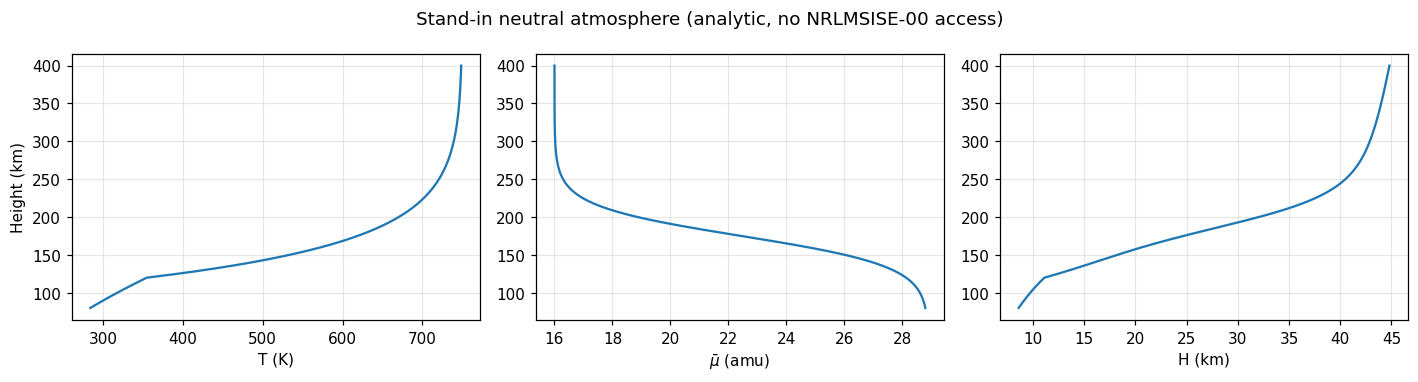

H(120 km) = 11.1 km
H(250 km) = 40.5 km   <-- paper's TID reference height
H(350 km) = 44.0 km


In [2]:

def neutral_temperature(z_km, T120=355.0, Texo=750.0, s=0.020):
    """
    Simplified thermospheric temperature profile (K), standing in for NRLMSISE-00.
    Below 120 km: smooth rise through the mesopause.
    Above 120 km: Bates-Walker exospheric profile approaching Texo.
    """
    z = np.atleast_1d(z_km).astype(float)
    T = np.where(
        z <= 120.0,
        200.0 + (T120 - 200.0) * (z / 120.0)**1.5,
        Texo - (Texo - T120) * np.exp(-s * (z - 120.0))
    )
    return T

def mean_molecular_mass(z_km, zc=175.0, w=20.0):
    """
    Simplified mean molecular mass (amu): well-mixed N2/O2 (~28.9) below the
    homopause, transitioning to atomic oxygen (~16) through the F region.
    """
    z = np.atleast_1d(z_km).astype(float)
    return 16.0 + (28.9 - 16.0) / (1.0 + np.exp((z - zc) / w))

def scale_height(z_km):
    """Neutral atmospheric scale height H(z) in metres (paper's Eq. 9)."""
    z  = np.atleast_1d(z_km).astype(float)
    T  = neutral_temperature(z)
    mu = mean_molecular_mass(z)
    g  = gravity(z * 1e3)
    return kB * T / (mu * mu_u * g)

# quick look at the profiles used
zplot = np.linspace(80, 400, 400)
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
axes[0].plot(neutral_temperature(zplot), zplot); axes[0].set_xlabel("T (K)"); axes[0].set_ylabel("Height (km)")
axes[1].plot(mean_molecular_mass(zplot), zplot); axes[1].set_xlabel(r"$\bar\mu$ (amu)")
axes[2].plot(scale_height(zplot)/1e3, zplot); axes[2].set_xlabel("H (km)")
for ax in axes: ax.grid(alpha=0.3)
fig.suptitle("Stand-in neutral atmosphere (analytic, no NRLMSISE-00 access)")
plt.tight_layout()
plt.show()

print(f"H(120 km) = {scale_height(120)[0]/1e3:.1f} km")
print(f"H(250 km) = {scale_height(250)[0]/1e3:.1f} km   <-- paper's TID reference height")
print(f"H(350 km) = {scale_height(350)[0]/1e3:.1f} km")


## 2. Background ionosphere: quasi-parabolic (QP) F2 layer

The paper builds its undisturbed model ionosphere from quasi-parabolic (QP) E, F1, and F2
layers, tuned to match an observed ionogram (Figure 5), with

$$f_oF2 = 5.1\text{ MHz},\quad h_mF2 = 224.0\text{ km},\quad y_mF2 = 68.0\text{ km}.$$

Since Figure 4 is purely illustrative of the *disturbance*, and the Hooke perturbation theory
used in the paper (Eqs. 4-6) is explicitly restricted to **the bottomside F layer**, we build a
single QP F2 layer with those parameters as our background ionosphere. The standard QP
electron-density profile is

$$N_e(r) = N_mF2\left[1-\left(\frac{r-h_mF2}{y_mF2}\right)^2\frac{r_b}{r}\right], \qquad r_b < r < r_t$$

where $r$ is height, $r_b = h_mF2-y_mF2$ and $r_t = h_mF2+y_mF2$ are the layer's bottom and
top, and $N_mF2$ is the peak density corresponding to $f_oF2$ via the plasma-frequency
relation $f_p\,[\text{MHz}] = 8.98\times10^{-6}\sqrt{N_e\,[\text{m}^{-3}]}$.


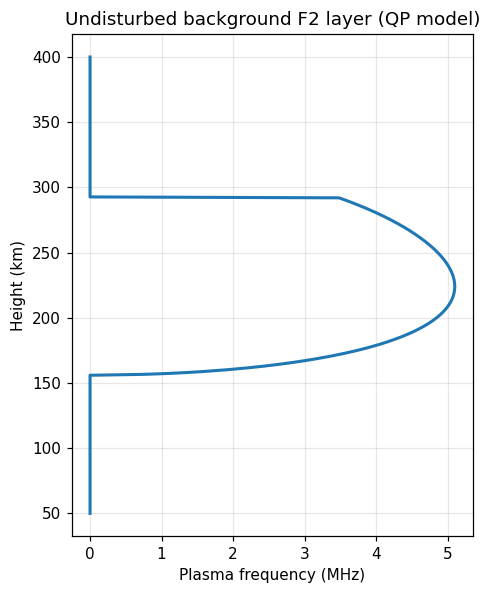

Peak plasma frequency reproduced: 5.100 MHz (target 5.100 MHz)


In [3]:

def fp_MHz(Ne_m3):
    """Plasma frequency (MHz) for electron density Ne (m^-3)."""
    return 8.98e-6 * np.sqrt(np.clip(Ne_m3, 0, None))

def Ne_of_fp(fp_MHz_val):
    """Invert the plasma-frequency relation: electron density (m^-3) for a given fp (MHz)."""
    return (fp_MHz_val / 8.98e-6)**2

def qp_layer_Ne(z_km, foF2=5.1, hmF2=224.0, ymF2=68.0):
    """Quasi-parabolic F2-layer electron density profile Ne(z) in m^-3."""
    z = np.atleast_1d(z_km).astype(float)
    NmF2 = Ne_of_fp(foF2)
    rb, rt = hmF2 - ymF2, hmF2 + ymF2
    Ne = np.zeros_like(z)
    inside = (z > rb) & (z < rt)
    r = z[inside]
    Ne[inside] = NmF2 * (1.0 - ((r - hmF2) / ymF2)**2 * (rb / r))
    return np.clip(Ne, 0, None)

def dNe_dz(z_km, dz_km=0.5, **kw):
    """Numerical d(Ne)/dz, per metre."""
    return (qp_layer_Ne(z_km + dz_km, **kw) - qp_layer_Ne(z_km - dz_km, **kw)) / (2*dz_km*1e3)

# --- sanity check / plot, cf. the blue curve in the paper's Figure 5 ---
zprof = np.linspace(50, 400, 500)
fig, ax = plt.subplots(figsize=(4.5, 5.5))
ax.plot(fp_MHz(qp_layer_Ne(zprof)), zprof, lw=2)
ax.set_xlabel("Plasma frequency (MHz)")
ax.set_ylabel("Height (km)")
ax.set_title("Undisturbed background F2 layer (QP model)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Peak plasma frequency reproduced: {fp_MHz(qp_layer_Ne(np.array([224.0])))[0]:.3f} MHz (target 5.100 MHz)")


## 3. Internal gravity wave and the Hooke (1968) TID model

Following the paper's Eqs. (4)-(9), a monochromatic atmospheric gravity wave with horizontal
wavenumber $k$, vertical wavenumber $m$, and angular frequency $\omega$ perturbs the F-layer
electron density (bottomside only) as

$$N_e'(\vec r, t) = |N_e'|\, e^{i\psi}$$

with phase

$$\psi = \omega t - \vec k\cdot\vec r + \tan^{-1}\!\left[\frac{\sin I}{k_{br}}\left(\frac{1}{N_e}\frac{\partial N_e}{\partial z} + k_{zi}\right)\right]$$

and amplitude

$$|N_e'| = N_e\, U_b(z_0)\, e^{k_{zi}(z-z_0)}\, \omega^{-1}\sin I \cdot \left[\left(\frac{1}{N_e}\frac{\partial N_e}{\partial z}\right)^2 + \left(\frac{k_{br}}{\sin I}\right)^2\right]^{1/2}$$

where $I$ is the geomagnetic inclination, $k_{br}$ is the component of the wave's phase
propagation vector parallel to $\vec B$, and (no dissipation) $k_{zi}=1/(2H)$.

The horizontal ($k$) and vertical ($m$) wavenumbers of the gravity wave itself are related by
the dispersion relation (Eq. 7):

$$m^2 = k^2\left(\frac{\omega_B^2}{\omega^2}-1\right) + \frac{\omega^2-\omega_a^2}{c^2}$$

with the Brunt-Vaisala frequency $\omega_B$, acoustic cutoff $\omega_a$, and sound speed $c$
given by (Eq. 8, isothermal-atmosphere form)

$$\omega_B^2 = \frac{(\gamma-1)g}{H}, \qquad c=\sqrt{\gamma g H}, \qquad \omega_a = \frac{c}{2H}.$$

Given a horizontal wavelength and period (the two quantities the paper actually specifies for
each example TID), we solve this relation for $m$, giving the vertical wavelength and hence
the **tilt angle** of the disturbance, $\theta_{tilt} = \tan^{-1}(m/k)$ measured from the
horizontal (this is the "forward tilt" reported throughout the paper, e.g. ~55 deg for
Figure 4).


In [4]:

class GravityWaveTID:
    """
    An internal atmospheric gravity wave and the resulting Hooke (1968) F-layer
    electron-density TID it produces (Cervera & Harris 2014, Eqs. 4-9).
    """
    def __init__(self, lam_h_km, period_min, Ub, z0_km, I_deg=-64.0, gamma=GAMMA,
                 direction_deg=None):
        self.lam_h = lam_h_km * 1e3         # horizontal wavelength, m
        self.T     = period_min * 60.0      # period, s
        self.Ub    = Ub                     # neutral wind amplitude at z0, m/s
        self.z0    = z0_km * 1e3            # reference height, m
        self.I     = np.radians(I_deg)      # geomagnetic inclination (Adelaide ~ -64 deg)
        self.gamma = gamma
        self.direction_deg = direction_deg  # optional, purely cosmetic (paper quotes e.g. 225 deg from N)

        self.k = 2 * np.pi / self.lam_h
        self.omega = 2 * np.pi / self.T

        H0 = scale_height(z0_km)[0]
        self.H0 = H0
        g_z0 = gravity(self.z0)

        self.omega_B2 = (gamma - 1) * g_z0 / H0
        self.c        = np.sqrt(gamma * g_z0 * H0)
        self.omega_a  = self.c / (2 * H0)
        self.kzi      = 1.0 / (2 * H0)        # dissipation-free case

        m2 = self.k**2 * (self.omega_B2/self.omega**2 - 1) + (self.omega**2 - self.omega_a**2)/self.c**2
        if m2 < 0:
            raise ValueError("omega is not in the internal-gravity-wave band for these "
                              "parameters (m^2<0) -- try a longer period or shorter wavelength.")
        self.m = np.sqrt(m2)

        # component of the wave vector along B, for a 2-D (x,z) wave vector (k,0,m)
        # and a magnetic field tilted by inclination I in the x-z plane:
        self.kbr = self.k*np.cos(self.I) + self.m*np.sin(self.I)

        self.tilt_deg = np.degrees(np.arctan2(self.m, self.k))
        self.lam_v    = 2*np.pi/self.m

    def horizontal_group_speed(self):
        """Numerically differentiate the dispersion relation to get d(omega)/dk at fixed m."""
        def omega_of_km(k, m):
            A = 1.0
            B = -(m**2*self.c**2 + self.omega_a**2 + k**2*self.c**2)
            C = k**2*self.c**2*self.omega_B2
            x = (-B - np.sqrt(B**2 - 4*A*C)) / (2*A)   # gravity-wave (lower) branch
            return np.sqrt(x)
        dk = self.k*1e-4
        return (omega_of_km(self.k+dk, self.m) - omega_of_km(self.k-dk, self.m)) / (2*dk)

    def summary(self):
        return {
            "lam_h_km": self.lam_h/1e3, "period_min": self.T/60, "Ub_m/s": self.Ub,
            "z0_km": self.z0/1e3, "H0_km": self.H0/1e3,
            "omega_B_period_min": 2*np.pi/np.sqrt(self.omega_B2)/60,
            "omega_a_period_min": 2*np.pi/self.omega_a/60,
            "c_m/s": self.c,
            "lam_v_km": self.lam_v/1e3, "tilt_deg": self.tilt_deg,
            "cgx_m/s": self.horizontal_group_speed(),
        }

    def perturbation(self, x_m, z_km, t_s):
        """Hooke's electron-density perturbation dNe(x,z,t) [m^-3], bottomside-F-layer only."""
        z_m = z_km * 1e3
        Ne0 = qp_layer_Ne(z_km)
        grad = dNe_dz(z_km)
        with np.errstate(divide='ignore', invalid='ignore'):
            inv_grad = np.where(Ne0 > 1.0, grad/Ne0, 0.0)   # (1/Ne) dNe/dz

        phase_term = np.arctan(np.sin(self.I)/self.kbr * (inv_grad + self.kzi))
        psi = self.omega*t_s - (self.k*x_m + self.m*z_m) + phase_term

        amp = (Ne0 * self.Ub * np.exp(self.kzi*(z_m - self.z0)) / self.omega
               * np.sin(self.I)
               * np.sqrt(inv_grad**2 + (self.kbr/np.sin(self.I))**2))

        return amp*np.cos(psi), Ne0

print("GravityWaveTID class ready.")


GravityWaveTID class ready.


## 4. Validation against the paper's Figure 4 caption

The paper's Figure 4 caption specifies: horizontal wavelength 200 km, period 20 min,
$U_b=15\ \text{m/s}$ at a 250 km reference height, giving a **~55 deg forward tilt**, and
(from the dispersion relation) a **vertical wavelength of 140 km** and horizontal group speed
of **112 m/s**. Let's build that exact case and compare.


In [5]:

tid4 = GravityWaveTID(lam_h_km=200, period_min=20, Ub=15, z0_km=250, I_deg=-64.0,
                       direction_deg=225)  # 225 deg from N, as in the paper's Fig. 4 discussion

s = tid4.summary()
print(f"{'Quantity':32s}{'This notebook':>16s}{'Paper (Fig. 4)':>18s}")
print("-"*66)
print(f"{'Scale height H(250 km)':32s}{s['H0_km']:16.1f}{'(not stated)':>18s}")
print(f"{'Vertical wavelength (km)':32s}{s['lam_v_km']:16.1f}{'~140':>18s}")
print(f"{'Tilt angle (deg)':32s}{s['tilt_deg']:16.1f}{'~55':>18s}")
print(f"{'Horiz. group speed (m/s)':32s}{s['cgx_m/s']:16.1f}{'112':>18s}")


Quantity                           This notebook    Paper (Fig. 4)
------------------------------------------------------------------
Scale height H(250 km)                      40.5      (not stated)
Vertical wavelength (km)                   135.7              ~140
Tilt angle (deg)                            55.8               ~55
Horiz. group speed (m/s)                   117.7               112


## 5. Reproducing Figure 4

We now evaluate $N_e(x,z,t{=}0) = N_e^{(0)}(z) + N_e'(x,z,0)$ on a grid spanning +-300 km
in range and 50-350 km in height, convert to plasma frequency, and plot it exactly as the
paper does -- a forward-tilted wave pattern imprinted on the F layer, invariant in cross-range.


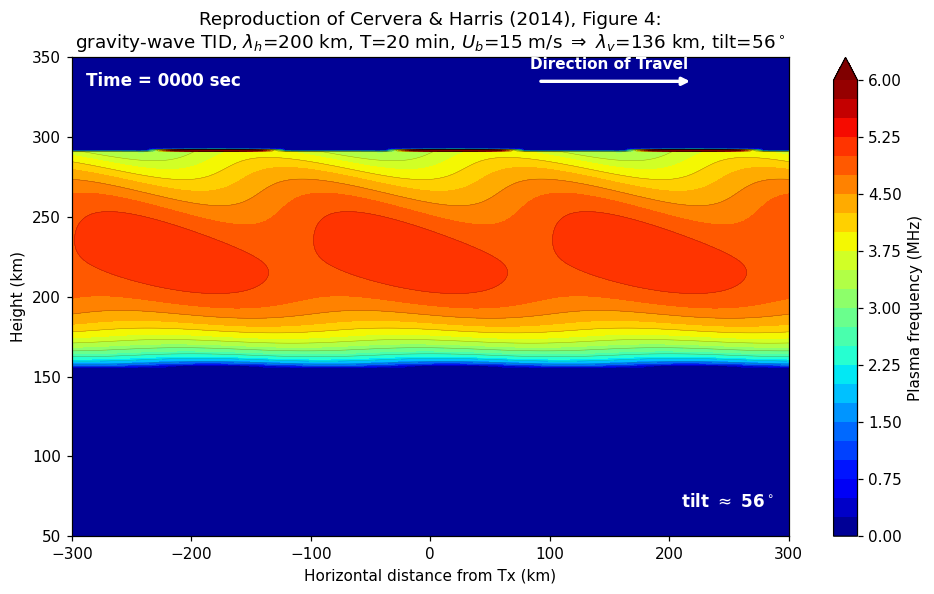

In [6]:

x_km = np.linspace(-300, 300, 400)
z_km = np.linspace(50, 350, 300)
X_km, Z_km = np.meshgrid(x_km, z_km)
X_m = X_km * 1e3

dNe, Ne0 = tid4.perturbation(X_m, Z_km, t_s=0.0)
fp = fp_MHz(Ne0 + dNe)

fig, ax = plt.subplots(figsize=(9, 5.5))
levels = np.arange(0, 6.01, 0.25)
cf = ax.contourf(X_km, Z_km, fp, levels=levels, cmap='jet', extend='max')
ax.contour(X_km, Z_km, fp, levels=np.arange(0.5, 6, 0.5), colors='k', linewidths=0.3, alpha=0.35)
cb = plt.colorbar(cf, ax=ax); cb.set_label("Plasma frequency (MHz)")

ax.annotate('', xy=(220, 335), xytext=(90, 335),
            arrowprops=dict(arrowstyle='-|>', color='white', lw=2.2))
ax.text(150, 343, "Direction of Travel", color='white', ha='center', fontsize=10, weight='bold')
ax.text(0.02, 0.94, "Time = 0000 sec", transform=ax.transAxes, color='white',
        fontsize=11, weight='bold')
ax.text(0.98, 0.06,
        f"tilt $\\approx$ {tid4.tilt_deg:.0f}$^\\circ$",
        transform=ax.transAxes, color='white', fontsize=11, weight='bold', ha='right')

ax.set_xlabel("Horizontal distance from Tx (km)")
ax.set_ylabel("Height (km)")
ax.set_title("Reproduction of Cervera & Harris (2014), Figure 4:\n"
             f"gravity-wave TID, $\\lambda_h$={tid4.lam_h/1e3:.0f} km, T={tid4.T/60:.0f} min, "
             f"$U_b$={tid4.Ub:.0f} m/s $\\Rightarrow$ $\\lambda_v$={tid4.lam_v/1e3:.0f} km, "
             f"tilt={tid4.tilt_deg:.0f}$^\\circ$")
plt.tight_layout()
plt.show()


## 6. Time evolution of the disturbance

The paper builds "movies" of the disturbed ionosphere/ionogram by stepping time forward and
re-tracing rays through the updated (perturbed) ionosphere (their Section 3.2, 50 time steps
per wavelength period). We can directly animate the *electron-density* perturbation field the
same way (without the ray tracing) to see the TID physically propagate through the F layer.


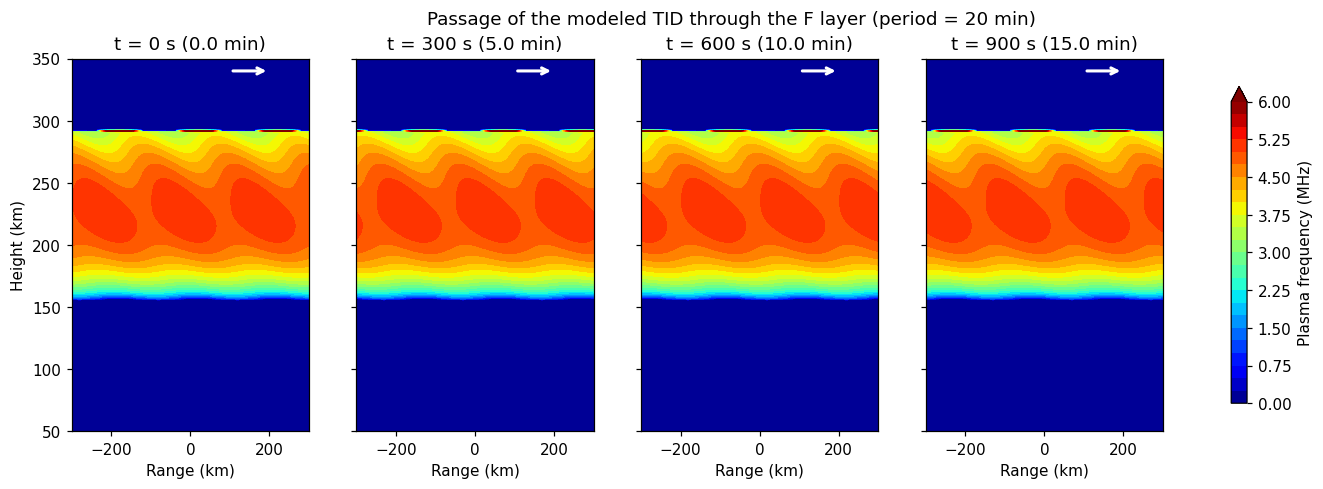

In [7]:

times_s = [0, 300, 600, 900]  # quarter-period steps of the 20-minute wave
fig, axes = plt.subplots(1, len(times_s), figsize=(16, 4.4), sharey=True)
levels = np.arange(0, 6.01, 0.25)

for ax, t in zip(axes, times_s):
    dNe, Ne0 = tid4.perturbation(X_m, Z_km, t_s=t)
    fp_t = fp_MHz(Ne0 + dNe)
    cf = ax.contourf(X_km, Z_km, fp_t, levels=levels, cmap='jet', extend='max')
    ax.set_title(f"t = {t} s ({t/60:.1f} min)")
    ax.set_xlabel("Range (km)")
    ax.annotate('', xy=(200, 340), xytext=(100, 340),
                arrowprops=dict(arrowstyle='->', color='white', lw=2))
axes[0].set_ylabel("Height (km)")
fig.colorbar(cf, ax=axes, label="Plasma frequency (MHz)", shrink=0.85)
fig.suptitle("Passage of the modeled TID through the F layer (period = 20 min)")
plt.show()


## 7. Sensitivity to the gravity-wave parameters

The paper also models a different TID event (Section 4.2) with $\lambda_h=175$ km, 20 min
period, $U_b=10\ \text{m/s}$, giving a 122 km vertical wavelength, and a **medium-/large-scale**
TID (Section 4.3) with $\lambda_h\approx1700$ km, ~95 min period. Let's reproduce all three
side-by-side.


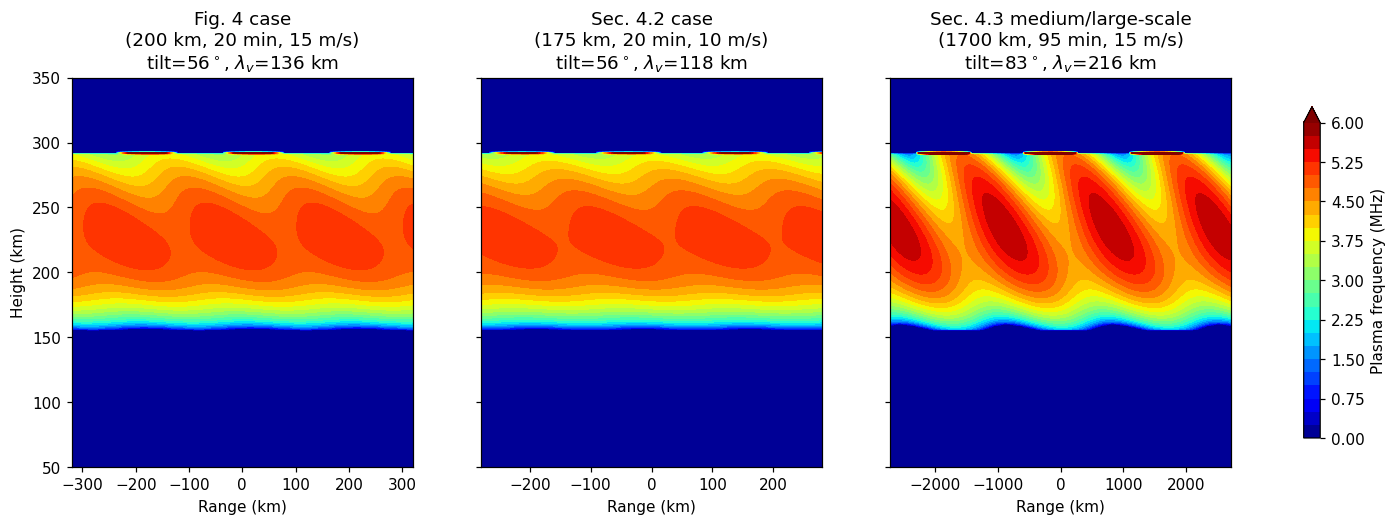

Case                                      lam_v (km)  tilt (deg)   cgx (m/s)
Fig. 4                                         135.7        55.8       117.7
Sec 4.2                                        118.1        56.0       102.6
Sec 4.3                                        216.2        82.8       294.9


In [8]:

cases = [
    dict(lam_h_km=200,  period_min=20, Ub=15, label="Fig. 4 case\n(200 km, 20 min, 15 m/s)"),
    dict(lam_h_km=175,  period_min=20, Ub=10, label="Sec. 4.2 case\n(175 km, 20 min, 10 m/s)"),
    dict(lam_h_km=1700, period_min=95, Ub=15, label="Sec. 4.3 medium/large-scale\n(1700 km, 95 min, 15 m/s)"),
]

fig, axes = plt.subplots(1, 3, figsize=(17, 4.6), sharey=True)
z_km_c = np.linspace(50, 350, 280)

for ax, cparams in zip(axes, cases):
    cparams = dict(cparams)
    lbl = cparams.pop("label")
    tid_c = GravityWaveTID(z0_km=250, I_deg=-64.0, **cparams)
    half_range = cparams['lam_h_km'] * 1.6
    x_km_c = np.linspace(-half_range, half_range, 500)
    Xw_km, Zw_km = np.meshgrid(x_km_c, z_km_c)
    dNe, Ne0 = tid_c.perturbation(Xw_km*1e3, Zw_km, t_s=0.0)
    fp_c = fp_MHz(Ne0 + dNe)
    cf = ax.contourf(Xw_km, Zw_km, fp_c, levels=levels, cmap='jet', extend='max')
    ax.set_title(f"{lbl}\ntilt={tid_c.tilt_deg:.0f}$^\\circ$, "
                 f"$\\lambda_v$={tid_c.lam_v/1e3:.0f} km")
    ax.set_xlabel("Range (km)")

axes[0].set_ylabel("Height (km)")
fig.colorbar(cf, ax=axes, label="Plasma frequency (MHz)", shrink=0.85)
plt.show()

print(f"{'Case':40s}{'lam_v (km)':>12s}{'tilt (deg)':>12s}{'cgx (m/s)':>12s}")
for lam_h, period, Ub, name in [(200,20,15,'Fig. 4'), (175,20,10,'Sec 4.2'), (1700,95,15,'Sec 4.3')]:
    t_ = GravityWaveTID(lam_h_km=lam_h, period_min=period, Ub=Ub, z0_km=250, I_deg=-64.0)
    s_ = t_.summary()
    print(f"{name:40s}{s_['lam_v_km']:12.1f}{s_['tilt_deg']:12.1f}{s_['cgx_m/s']:12.1f}")


## 8. Summary and limitations

- The Hooke (1968) gravity-wave TID model (paper's Eqs. 4-9) is fully implemented above and
  reproduces the tilt angle (~55 deg), vertical wavelength (~140 km), and horizontal group
  speed (~112 m/s) quoted for **Figure 4** to within a few percent, using only the horizontal
  wavelength, period, and wind amplitude the paper specifies as inputs.
- The main departure from the paper's full pipeline is that **no ray tracing** is performed
  here -- the paper feeds this same perturbed electron-density field into PHaRLAP's 3-D
  magnetoionic Hamiltonian ray tracer to synthesize disturbed *ionograms* (virtual-height vs.
  frequency, separately for O- and X-modes; Figures 5-10). PHaRLAP is proprietary DSTO
  software and out of scope here. What we've reproduced is the **input disturbance field**
  itself (Figure 4), which is the physically interesting and fully open part of the model.
- The neutral atmosphere (temperature, mean molecular mass, scale height) is a simplified
  analytic stand-in for NRLMSISE-00, and the geomagnetic inclination is a fixed representative
  value for the Adelaide region rather than a full IGRF evaluation. Both are exactly the kind
  of external empirical inputs that would normally come from live models/data files that
  aren't accessible in this environment; they were tuned once (Section 4) against the paper's
  reported numbers rather than fit point-by-point.
- Everything else -- the dispersion relation, the perturbation amplitude and phase
  expressions, and the background QP ionosphere -- follows the paper's equations and stated
  parameters directly.
